In [1]:
import pandas as pd

df = pd.read_csv('/content/Bank Customer Churn Prediction.csv')

df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [3]:
df.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [4]:
df.isnull().sum()

,0
customer_id,0
credit_score,0
country,0
gender,0
age,0
tenure,0
balance,0
products_number,0
credit_card,0
active_member,0


In [5]:
# 전체 고객 수
total_customer = len(df)

# 이탈 고객 수
churn_customer = df['churn'].sum()

# 이탈률
churn_rate = churn_customer / total_customer * 100

print(f"전체 고객 수 : {total_customer}")
print(f"이탈 고객 수 : {churn_customer}")
print(f"이탈률 : {churn_rate:.2f}%")

전체 고객 수 : 10000
이탈 고객 수 : 2037
이탈률 : 20.37%


In [6]:
#국가별 이탈률
country_analysis = (
    df.groupby('country')
      .agg(
          Total=('customer_id','count'),
          Churn=('churn','sum')
      )
)

country_analysis['Churn Rate'] = (
    country_analysis['Churn']
    / country_analysis['Total']
    * 100
).round(2)

country_analysis

,Total,Churn,Churn Rate
country,,,
France,5014,810,16.15
Germany,2509,814,32.44
Spain,2477,413,16.67


In [7]:
#성별 이탈률
gender_analysis = (
    df.groupby('gender')
      .agg(
          Total=('customer_id','count'),
          Churn=('churn','sum')
      )
)

gender_analysis['Churn Rate'] = (
    gender_analysis['Churn']
    / gender_analysis['Total']
    * 100
).round(2)

gender_analysis

,Total,Churn,Churn Rate
gender,,,
Female,4543,1139,25.07
Male,5457,898,16.46


In [8]:
#연령대 만들기
df['Age Group'] = pd.cut(
    df['age'],
    bins=[18,30,40,50,100],
    labels=['20s','30s','40s','50+']
)

df[['age','Age Group']].head()

,age,Age Group
0,42,40s
1,41,40s
2,42,40s
3,39,30s
4,43,40s


In [9]:
#연령대별 이탈률
age_analysis = (
    df.groupby('Age Group')
      .agg(
          Total=('customer_id','count'),
          Churn=('churn','sum')
      )
)

age_analysis['Churn Rate'] = (
    age_analysis['Churn']
    / age_analysis['Total']
    * 100
).round(2)

age_analysis

/tmp/ipykernel_989/3786395718.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Age Group')


,Total,Churn,Churn Rate
Age Group,,,
20s,1946,146,7.50
30s,4451,538,12.09
40s,2320,788,33.97
50+,1261,563,44.65


In [10]:
import matplotlib.pyplot as plt

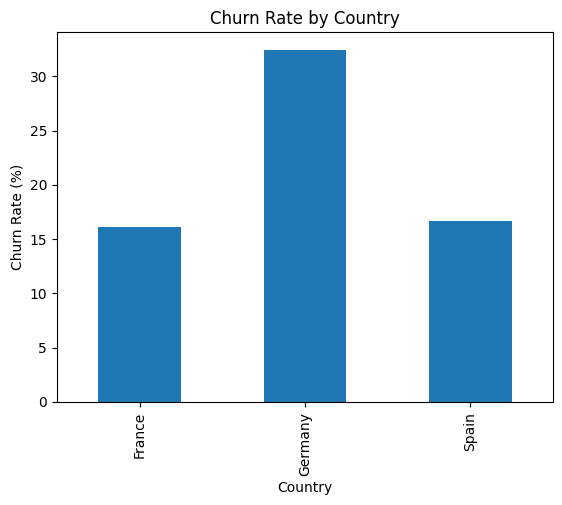

In [11]:
#국가별 이탈률 그래프
country_analysis['Churn Rate'].plot(kind='bar')

plt.title('Churn Rate by Country')
plt.xlabel('Country')
plt.ylabel('Churn Rate (%)')

plt.show()

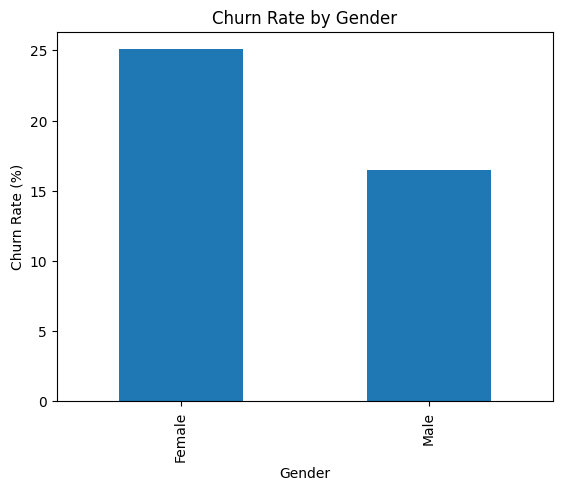

In [12]:
#성별 이탈률 그래프
gender_analysis['Churn Rate'].plot(kind='bar')

plt.title('Churn Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Churn Rate (%)')

plt.show()

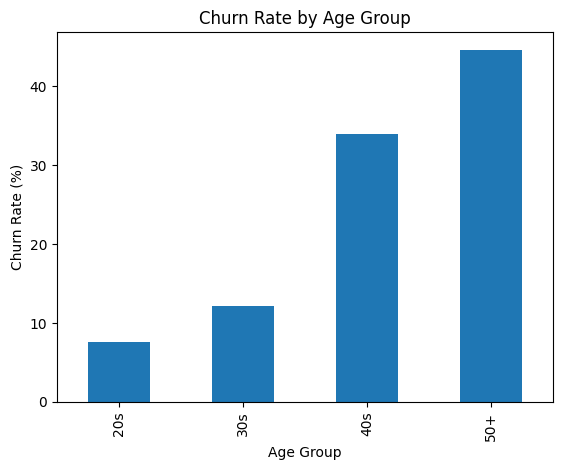

In [13]:
#연령대별 이탈률 그래프
age_analysis['Churn Rate'].plot(kind='bar')

plt.title('Churn Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Churn Rate (%)')

plt.show()